In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("data/cleaned/sales_cleaned.xlsx")

print(df.head())
print(df.columns)

    order_id  order_date    status   item_id                  sku  \
0  100354678       44105  received  574772.0   oasis_Oasis-064-36   
1  100354678       44105  received  574774.0      Fantastic_FT-48   
2  100354680       44105  complete  574777.0      mdeal_DMC-610-8   
3  100354680       44105  complete  574779.0   oasis_Oasis-061-36   
4  100367357       44148  received  595185.0  MEFNAR59C38B6CA08CD   

   qty_ordered  price   value  discount_amount   total  ...          ssn  \
0         21.0   89.9  1798.0              0.0  1798.0  ...  627-31-5251   
1         11.0   19.0   190.0              0.0   190.0  ...  627-31-5251   
2          9.0  149.9  1199.2              0.0  1199.2  ...  627-31-5251   
3          9.0   79.9   639.2              0.0   639.2  ...  627-31-5251   
4          2.0   99.9    99.9              0.0    99.9  ...  627-31-5251   

      phone_no_ place_name  county    city state      zip region user_name  \
0  405-959-1129     Vinson  Harmon  Vinson    OK  

In [7]:
df.columns.tolist()


['order_id',
 'order_date',
 'status',
 'item_id',
 'sku',
 'qty_ordered',
 'price',
 'value',
 'discount_amount',
 'total',
 'category',
 'payment_method',
 'bi_st',
 'cust_id',
 'year',
 'month',
 'ref_num',
 'name_prefix',
 'first_name',
 'middle_initial',
 'last_name',
 'gender',
 'age',
 'full_name',
 'e_mail',
 'customer_since',
 'ssn',
 'phone_no_',
 'place_name',
 'county',
 'city',
 'state',
 'zip',
 'region',
 'user_name',
 'discount_percent']

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

df = pd.read_excel("data/cleaned/sales_cleaned.xlsx")

In [10]:
total_revenue = df["total"].sum()
total_orders = df["order_id"].nunique()
total_customers = df["cust_id"].nunique()
aov = total_revenue / total_orders

print(f"Total Revenue : ${total_revenue:,.2f}")
print(f"Total Orders : {total_orders}")
print(f"Total Customers : {total_customers}")
print(f"Average Order Value : ${aov:,.2f}")

Total Revenue : $182,871,620,639,006,851,072.00
Total Orders : 201716
Total Customers : 64248
Average Order Value : $906,579,649,799,752.38


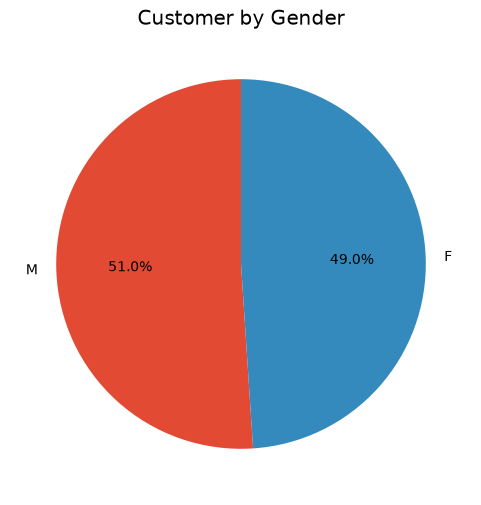

In [11]:
plt.figure(figsize=(6,6))

gender = df["gender"].value_counts()

plt.pie(
    gender,
    labels=gender.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer by Gender")

plt.show()

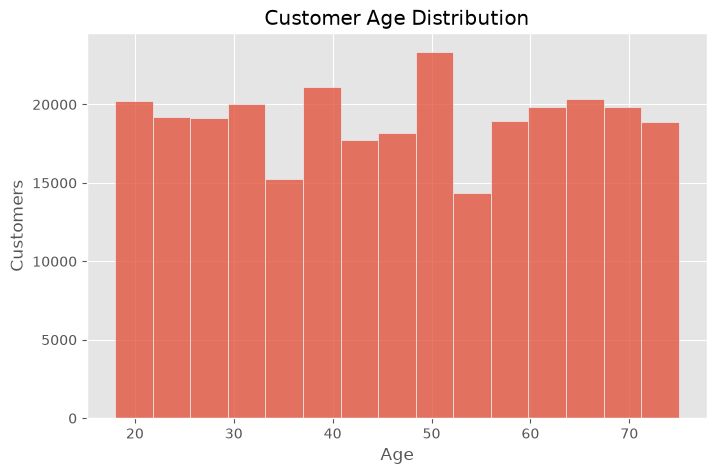

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=15)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Customers")

plt.show()

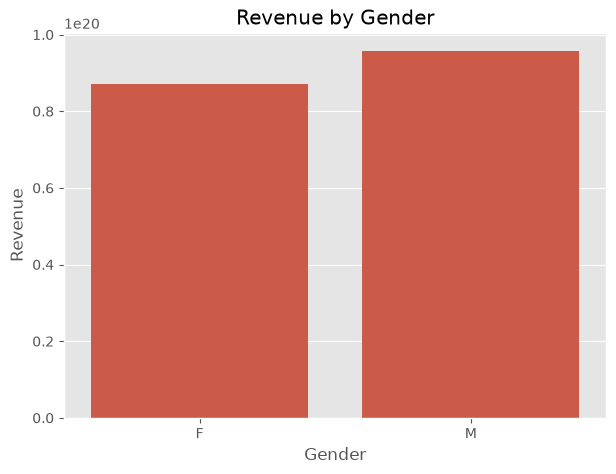

In [13]:
plt.figure(figsize=(7,5))

gender_revenue = df.groupby("gender")["total"].sum()

sns.barplot(
    x=gender_revenue.index,
    y=gender_revenue.values
)

plt.title("Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Revenue")

plt.show()

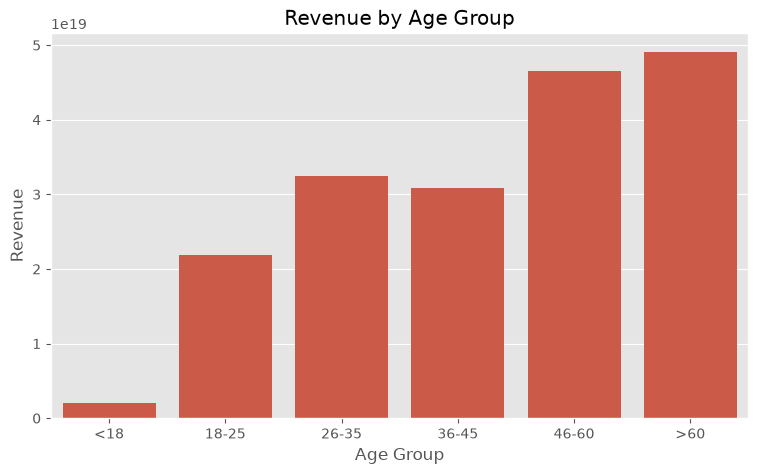

In [14]:
bins = [0,18,25,35,45,60,100]

labels = [
    "<18",
    "18-25",
    "26-35",
    "36-45",
    "46-60",
    ">60"
]

df["Age Group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels
)

age_revenue = (
    df.groupby("Age Group")["total"]
      .sum()
)

plt.figure(figsize=(9,5))

sns.barplot(
    x=age_revenue.index,
    y=age_revenue.values
)

plt.title("Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Revenue")

plt.show()